In [1]:
import os
import shutil
shutil.rmtree('__pycache__', ignore_errors=True)

from utils import *
from index import SyntheticGenerator

# Visualização 3D Step-by-Step
Cada subplot mostra um passo do pipeline de geração sísmica como um cubo 3D com 3 faces visíveis (back wall, side wall, floor).

- **a) Reflectivity** — Camadas horizontais planas
- **b) Folding** — Dobramentos Gaussianos
- **c) Shearing** — Cisalhamento/inclinação planar
- **d) Faulting** — Falhas com deslocamento
- **e) Wavelet** — Convolução com wavelet de Ricker
- **f) Noise** — Ruído gaussiano adicionado

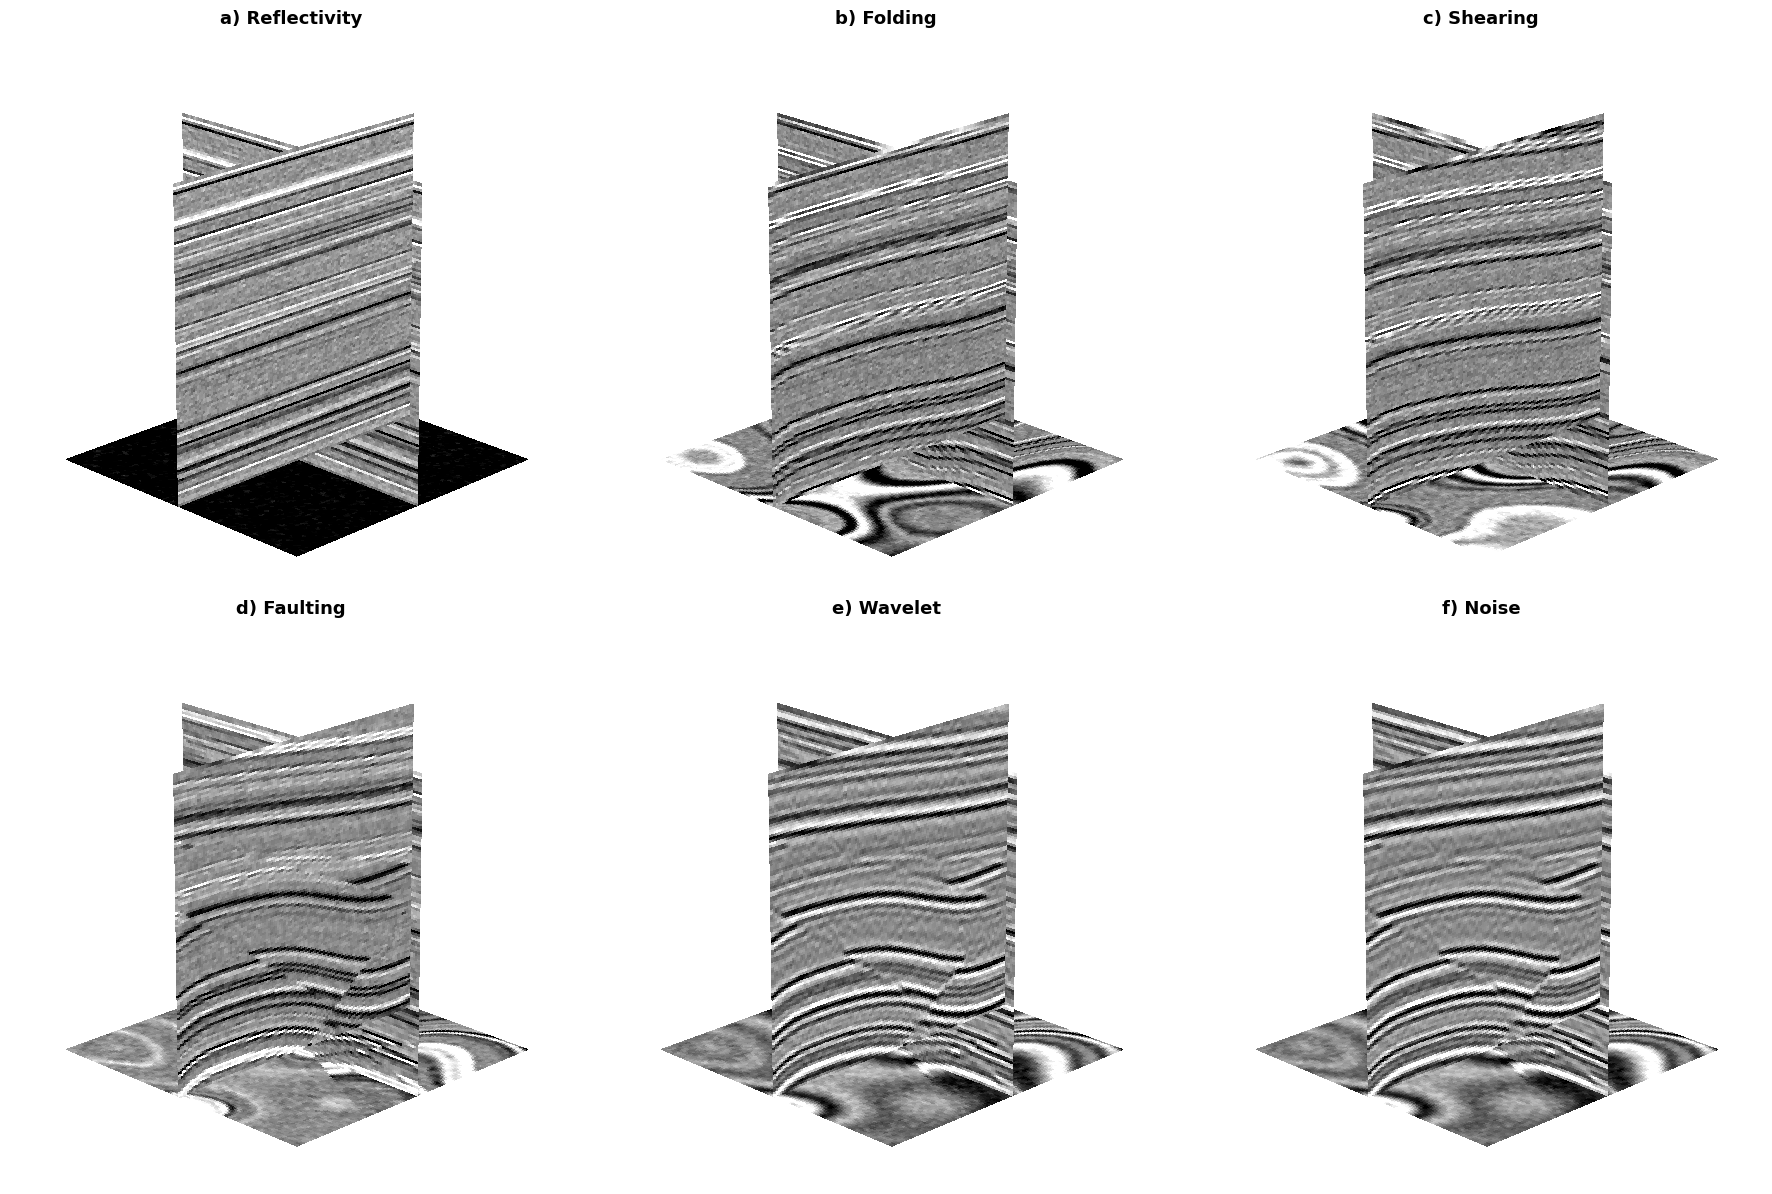

In [2]:
gen = SyntheticGenerator()
gen.prepare()

reflectivity = gen.genReflectivity()
folded  = gen.applyFolding(reflectivity)
sheared = gen.applyShearing(folded)
faulted, mask = gen.applyFaulting(sheared)
seismic = gen.applyWavelet(faulted)
noisy = gen.applyNoise(seismic)

steps = [
    (gen.crop(reflectivity), 'a) Reflectivity'),
    (gen.crop(folded),       'b) Folding'),
    (gen.crop(sheared),      'c) Shearing'),
    (gen.crop(faulted),      'd) Faulting'),
    (gen.crop(seismic),      'e) Wavelet'),
    (gen.crop(noisy),        'f) Noise'),
]

showSteps(steps)

# APLICANDO DATASET

In [3]:
SAVE_DATA = False

if not SAVE_DATA:
    raise Exception('save_data=false, saindo do programa')

Exception: save_data=false, saindo do programa

In [ ]:
variations = {
    'shearGradient': [(0.0, 0.0), (-0.1, 0.1), (-0.3, 0.3)],
    'waveletFreq': [(5, 15), (20, 35), (45, 65), (70, 90), (100, 120)],
    'waveletDuration': [0.04, 0.06],
    'waveletDt': [0.0005, 0.001, 0.01, 0.1, 0.5],
    
    'layerNoise': [0.0, 0.01, 0.08, 0.001],
    'layerRange': [(20, 50), (80, 160), (250, 350)],
    'layerThickness': [(1, 1), (1, 3), (5, 10)],
    'foldCount': [(0, 3), (15, 30), (60, 90)],
    'foldSigma': [(5, 15), (15, 80), (120, 200)],
    'foldAmplitude': [(-5, 5), (-30, 30), (-80, 80)],
    'foldDamping': [0.0, 1.5, 5.0],

    'noiseLevel': [(0.0, 0.0), (0.01, 0.05), (0.1, 0.25), (0.2, 0.4)],
}

for label, values in variations.items():
    for value in values:
        safe_value = str(value).replace(' ', '').replace('(', '').replace(')', '').replace(',', '_')
        path = os.path.join('variations', f"{label}_{safe_value}")
        setFolder(path)

        for i in range(3):
            print(f"Gerando variação {i}: {label} = {value}")

            try:
                gen = SyntheticGenerator()
                setattr(gen, label, value)
                gen.prepare()
                
                reflectivity = gen.genReflectivity()
                folded  = gen.applyFolding(reflectivity)
                sheared = gen.applyShearing(folded)
                faulted, mask = gen.applyFaulting(sheared)
                seismic = gen.applyWavelet(faulted)
                noisy = gen.applyNoise(seismic)

                steps = [
                    (gen.crop(reflectivity), 'a) Reflectivity'),
                    (gen.crop(folded),       'b) Folding'),
                    (gen.crop(sheared),      'c) Shearing'),
                    (gen.crop(faulted),      'd) Faulting'),
                    (gen.crop(seismic),      'e) Wavelet'),
                    (gen.crop(noisy),        'f) Noise'),
                ]

                # 1. Salvar a imagem dos passos 3D
                out_image_path = os.path.join(path, f'images/image_{i}.png')
                showSteps(steps, save=out_image_path)
                
                # 2. Salvar a imagem da MÁSCARA 2D
                cropped_mask = gen.crop(mask)
                mask_image_path = os.path.join(path, f'masks/image_{i}.png')
                showTile(cropped_mask, mask=True, save=mask_image_path)
                plt.close('all') 
                
                # 3. Salvar o JSON
                json_path = os.path.join(path, 'info.json')
                with open(json_path, 'w') as file:
                    json.dump(gen.getMetrics(), file, indent=4)
            except Exception as error:
                print(f'error in {label} (var {i})', error)

Gerando variação 0: shearGradient = (0.0, 0.0)
